<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/Practice_Medical_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [5]:
url1=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Normal.csv')
url2=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Type_H.csv')
url3=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Type_S.csv')

In [6]:
print(url1.shape)
print(url2.shape)
print(url3.shape)

(100, 7)
(60, 7)
(150, 7)


In [7]:
if set(url1.columns)== set(url2.columns)== set(url3.columns):
  print('all columns are same')
else:
  print('kuch gadbad h')

all columns are same


In [8]:
df=pd.concat([url1,url2,url3])

In [9]:
df.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [10]:
df.shape

(310, 7)

In [11]:
df['Class'].value_counts()

,count
Class,
Type_S,133
Normal,73
Type_H,37
Nrmal,27
type_h,23
tp_s,17


In [12]:
df['Class']=df['Class'].replace('Nrmal','Normal')
df['Class']=df['Class'].replace('tp_s','Type_S')
df['Class']=df['Class'].replace('type_h','Type_H')

In [13]:
df['Class'].value_counts()

,count
Class,
Type_S,150
Normal,100
Type_H,60


In [14]:
df.isna().sum()

,0
P_incidence,0
P_tilt,0
L_angle,0
S_slope,0
P_radius,0
S_Degree,0
Class,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [18]:
df[df.index.duplicated()].count()

,0
P_incidence,160
P_tilt,160
L_angle,160
S_slope,160
P_radius,160
S_Degree,160
Class,160


In [ ]:
df.index.

In [30]:
df.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [31]:
df.dtypes

,0
P_incidence,float64
P_tilt,float64
L_angle,float64
S_slope,float64
P_radius,float64
S_Degree,float64
Class,object


In [33]:
pd.DataFrame({'data_type': df.dtypes,'unique_count':df.nunique()})

,data_type,unique_count
P_incidence,float64,310
P_tilt,float64,310
L_angle,float64,280
S_slope,float64,281
P_radius,float64,310
S_Degree,float64,310
Class,object,3


<Axes: >

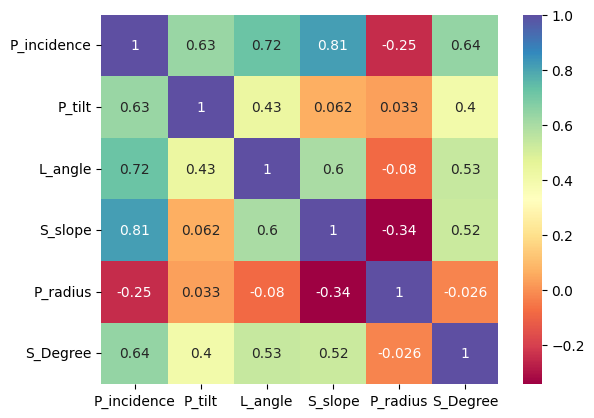

In [35]:
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),annot=True, cmap='Spectral')

P_incidence & S_slope have stronger positive co-relation

P_incidence & L_angle also have positive co-relation

S_Degree & P_radius have stronger negative correaltion

<Figure size 800x600 with 0 Axes>

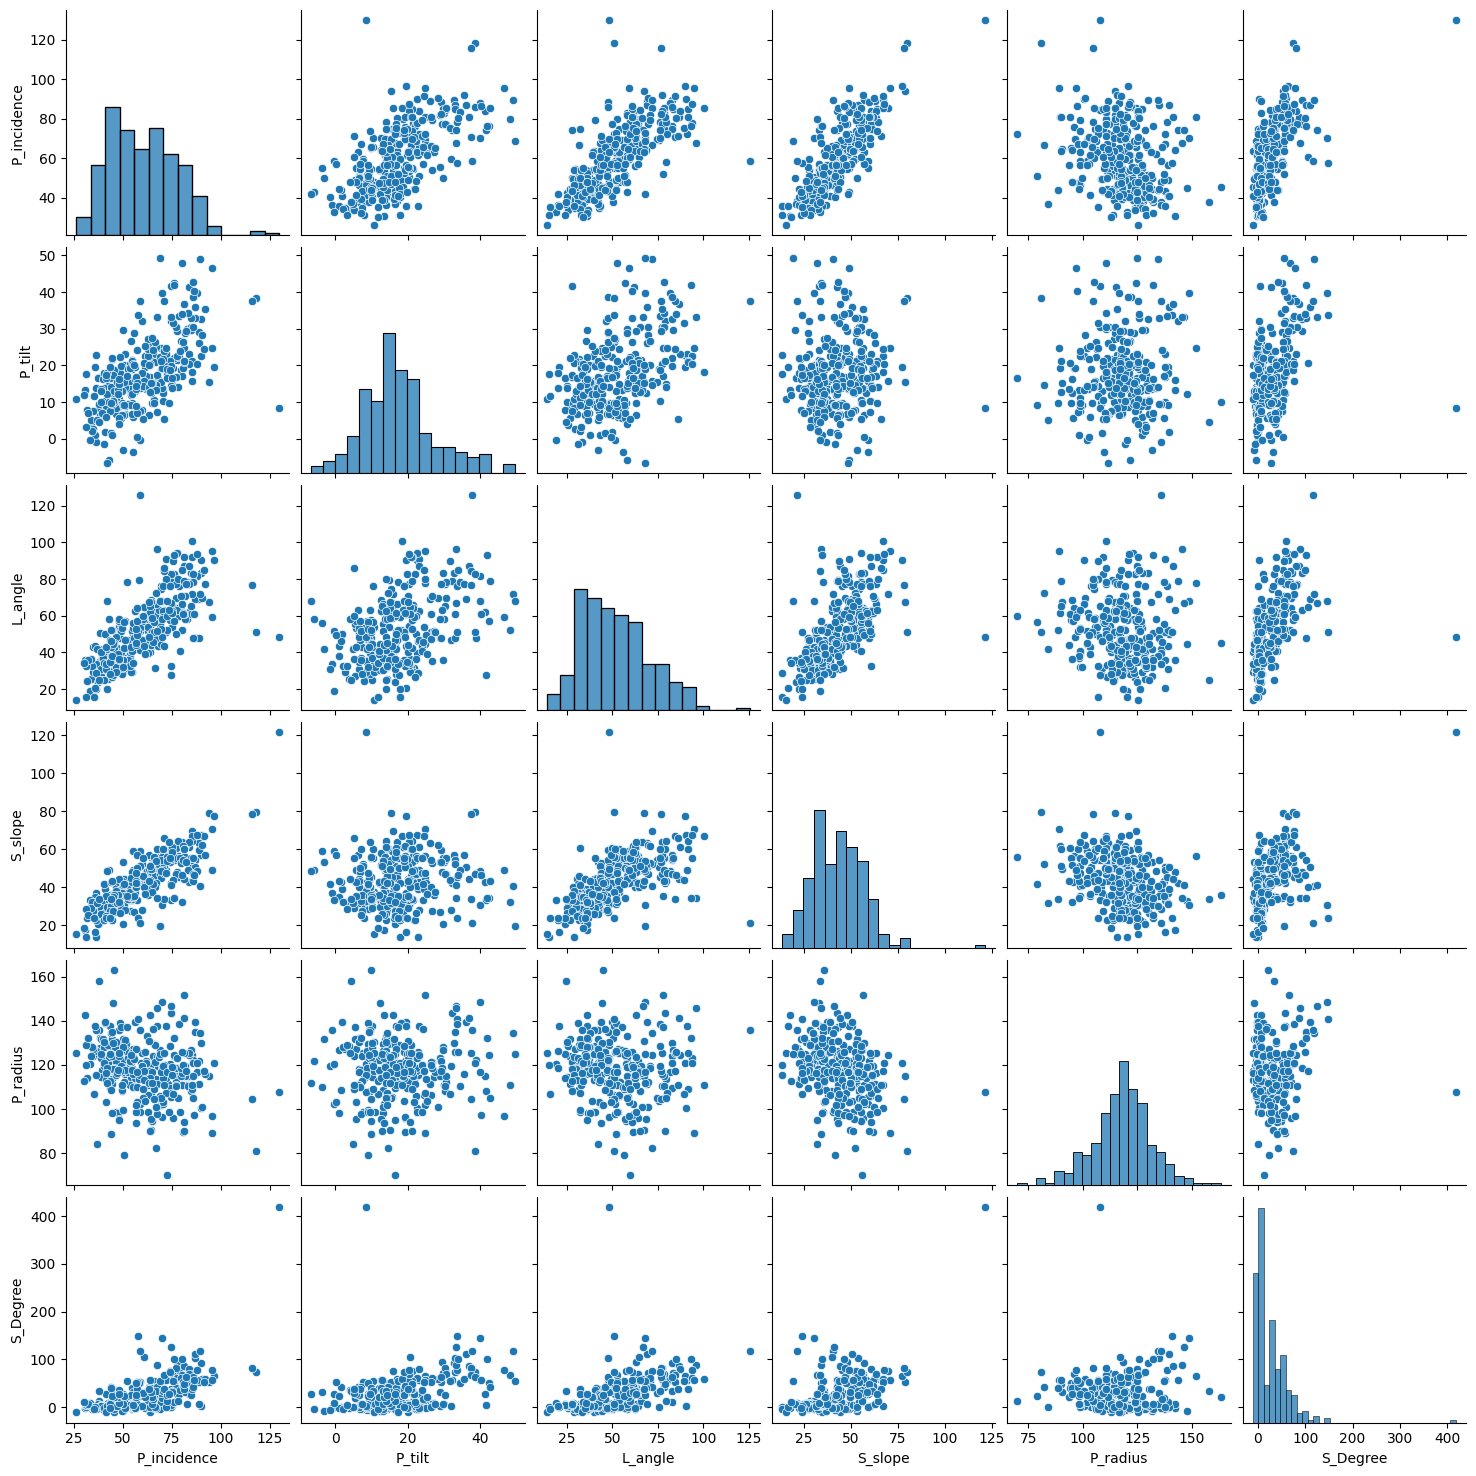

In [49]:
plt.figure(figsize=(8,6))
sns.pairplot(df)
plt.show()

In [42]:
X=df.drop(['Class'],axis=1)
y=df['Class']

In [43]:
X.shape

(310, 6)

In [44]:
y.shape

(310,)

In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [47]:
X_train.columns

Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree'], dtype='object')

In [51]:
y_train.value_counts()

,count
Class,
Type_S,117
Normal,82
Type_H,49


In [52]:
y_test.value_counts()

,count
Class,
Type_S,33
Normal,18
Type_H,11


In [55]:
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [58]:
knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [59]:
y_train_pred=knn.predict(X_train_scaled)
y_test_pred=knn.predict(X_test_scaled)

In [60]:
accuracy_score(y_test,y_test_pred)

0.7258064516129032

In [61]:
accuracy_score(y_train,y_train_pred)

0.8467741935483871

In [64]:
print('\n',classification_report(y_test,y_test_pred))


               precision    recall  f1-score   support

      Normal       0.57      0.67      0.62        18
      Type_H       0.67      0.73      0.70        11
      Type_S       0.86      0.76      0.81        33

    accuracy                           0.73        62
   macro avg       0.70      0.72      0.71        62
weighted avg       0.74      0.73      0.73        62



array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,